In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sklearn.cluster import KMeans

sns.set(style="whitegrid")

In [2]:
import pandas as pd
import os
df = pd.read_csv(r"C:\Users\dell\Desktop\Data_AN_poke\data\Pokemon.csv")
df.head()

,Rank,Id,Pokemon,Type1,Type2,Total,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,Generation,Legendary,Usage%,Raw,Raw%,Real,Real%,Date
0,1,248,Tyranitar,Rock,Dark,600,100,134,110,95,100,61,2,False,47.24692%,40707,42.224%,33670,42.976%,2021/10
1,2,376,Metagross,Steel,Psychic,600,80,135,130,95,90,70,3,False,37.54496%,33692,34.947%,27674,35.322%,2021/10
2,3,260,Swampert,Water,Ground,535,100,110,90,85,90,60,3,False,30.09949%,27364,28.384%,22652,28.913%,2021/10
3,4,373,Salamence,Dragon,Flying,600,95,135,80,110,80,100,3,False,30.08224%,28170,29.220%,22774,29.068%,2021/10
4,5,94,Gengar,Ghost,Poison,500,60,65,60,130,75,110,1,False,27.24814%,26840,27.840%,21269,27.147%,2021/10


In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Rank            1000 non-null   int64   
 1   Id              1000 non-null   int64   
 2   Pokemon         1000 non-null   object  
 3   Type1           1000 non-null   object  
 4   Type2           1000 non-null   object  
 5   Total           1000 non-null   int64   
 6   HP              1000 non-null   int64   
 7   Attack          1000 non-null   int64   
 8   Defense         1000 non-null   int64   
 9   Sp.Atk          1000 non-null   int64   
 10  Sp.Def          1000 non-null   int64   
 11  Speed           1000 non-null   int64   
 12  Generation      1000 non-null   int64   
 13  Legendary       1000 non-null   object  
 14  Usage%          1000 non-null   object  
 15  Raw             1000 non-null   int64   
 16  Raw%            1000 non-null   object  
 17  Real           

,Rank,Id,Total,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,Generation,Raw,Real,Offense,Defense_Total,Balance
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.500000,210.24400,524.087000,85.859000,89.521000,85.444000,87.822000,90.722000,84.719000,1.943000,10069.275000,8232.295000,177.343000,176.166000,38.599000
std,11.549172,101.64307,49.348198,36.236448,27.060522,30.344615,26.459373,24.960845,27.600831,0.845261,8752.031288,7288.108823,33.746588,37.254723,33.955164
min,1.000000,3.00000,405.000000,35.000000,10.000000,10.000000,40.000000,45.000000,25.000000,1.000000,1087.000000,779.000000,85.000000,95.000000,0.000000
25%,10.750000,134.00000,500.000000,61.000000,70.000000,65.000000,60.000000,75.000000,65.000000,1.000000,3567.250000,2860.750000,160.000000,150.000000,10.000000
50%,20.500000,229.00000,525.000000,80.000000,90.000000,80.000000,95.000000,90.000000,81.000000,2.000000,6489.000000,5352.500000,180.000000,175.000000,30.000000
75%,30.250000,286.00000,540.000000,95.000000,110.000000,100.000000,110.000000,100.000000,100.000000,3.000000,14437.000000,11290.750000,195.000000,200.000000,60.000000
max,40.000000,385.00000,670.000000,255.000000,160.000000,180.000000,135.000000,200.000000,160.000000,3.000000,44098.000000,36980.000000,255.000000,300.000000,150.000000


In [16]:
# Missing values
df.isnull().sum()

# Fill missing Type 2
df['Type2'].fillna('None', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

df.shape

C:\Users\dell\AppData\Local\Temp\ipykernel_19244\4060457295.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type2'].fillna('None', inplace=True)


(1000, 26)

In [17]:
df.head(5)

,Rank,Id,Pokemon,Type1,Type2,Total,HP,Attack,Defense,Sp.Atk,...,Raw%,Real,Real%,Date,Strength,Offense,Defense_Total,Balance,Speed_Category,Role
0,1,248,Tyranitar,Rock,Dark,600,100,134,110,95,...,42.224%,33670,42.976%,2021/10,Strong,229,210,19,Average,Attacker
1,2,376,Metagross,Steel,Psychic,600,80,135,130,95,...,34.947%,27674,35.322%,2021/10,Strong,230,220,10,Average,Attacker
2,3,260,Swampert,Water,Ground,535,100,110,90,85,...,28.384%,22652,28.913%,2021/10,Strong,195,180,15,Average,Attacker
3,4,373,Salamence,Dragon,Flying,600,95,135,80,110,...,29.220%,22774,29.068%,2021/10,Strong,245,160,85,Average,Attacker
4,5,94,Gengar,Ghost,Poison,500,60,65,60,130,...,27.840%,21269,27.147%,2021/10,Weak,195,135,60,Fast,Attacker


In [18]:
# Total stats
df['Total'] = df[['HP', 'Attack', 'Defense', 'Sp.Atk', 'Sp.Def', 'Speed']].sum(axis=1)

# Offensive & Defensive
df['Offense'] = df['Attack'] + df['Sp.Atk']
df['Defense_Total'] = df['Defense'] + df['Sp.Def']

# Balance score
df['Balance'] = abs(df['Offense'] - df['Defense_Total'])

# Speed category
df['Speed_Category'] = pd.cut(
    df['Speed'],
    bins=[0, 50, 100, 150, 200],
    labels=['Slow', 'Average', 'Fast', 'Very Fast']
)

# Role classification
df['Role'] = df.apply(
    lambda x: 'Attacker' if x['Offense'] > x['Defense_Total'] else 'Tank',
    axis=1
)

df.head()


,Rank,Id,Pokemon,Type1,Type2,Total,HP,Attack,Defense,Sp.Atk,...,Raw%,Real,Real%,Date,Strength,Offense,Defense_Total,Balance,Speed_Category,Role
0,1,248,Tyranitar,Rock,Dark,600,100,134,110,95,...,42.224%,33670,42.976%,2021/10,Strong,229,210,19,Average,Attacker
1,2,376,Metagross,Steel,Psychic,600,80,135,130,95,...,34.947%,27674,35.322%,2021/10,Strong,230,220,10,Average,Attacker
2,3,260,Swampert,Water,Ground,535,100,110,90,85,...,28.384%,22652,28.913%,2021/10,Strong,195,180,15,Average,Attacker
3,4,373,Salamence,Dragon,Flying,600,95,135,80,110,...,29.220%,22774,29.068%,2021/10,Strong,245,160,85,Average,Attacker
4,5,94,Gengar,Ghost,Poison,500,60,65,60,130,...,27.840%,21269,27.147%,2021/10,Weak,195,135,60,Fast,Attacker


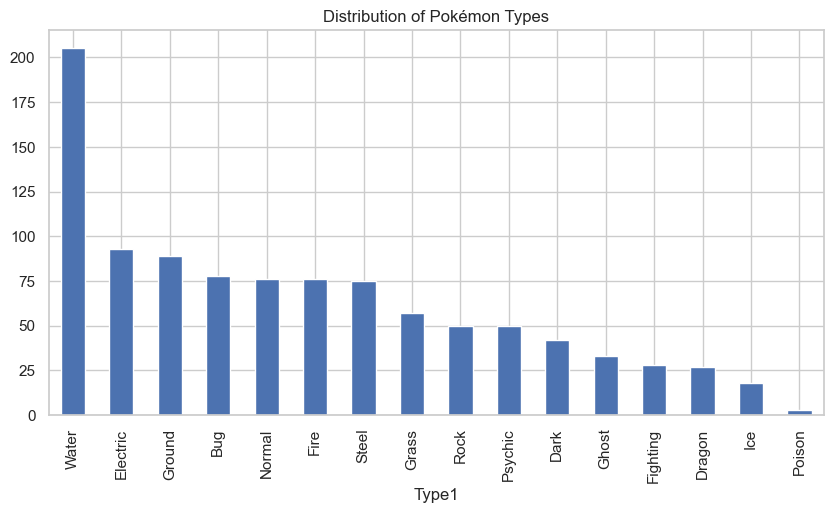

In [20]:
# Type distribution
plt.figure(figsize=(10,5))
df['Type1'].value_counts().plot(kind='bar')
plt.title("Distribution of Pokémon Types")
plt.show()

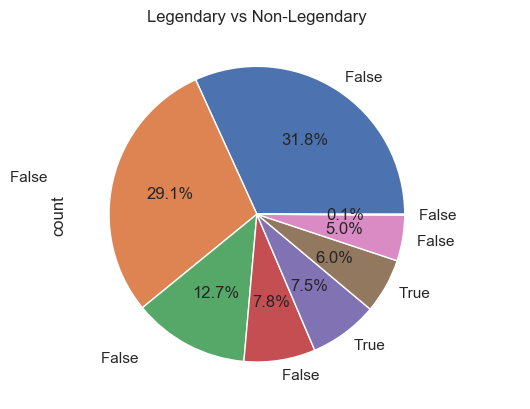

In [21]:
df['Legendary'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Legendary vs Non-Legendary")
plt.show()

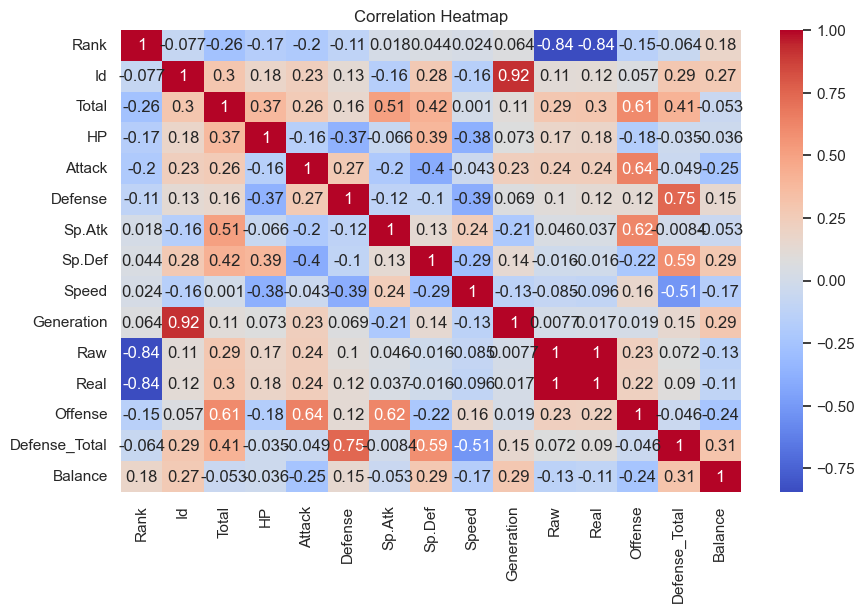

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

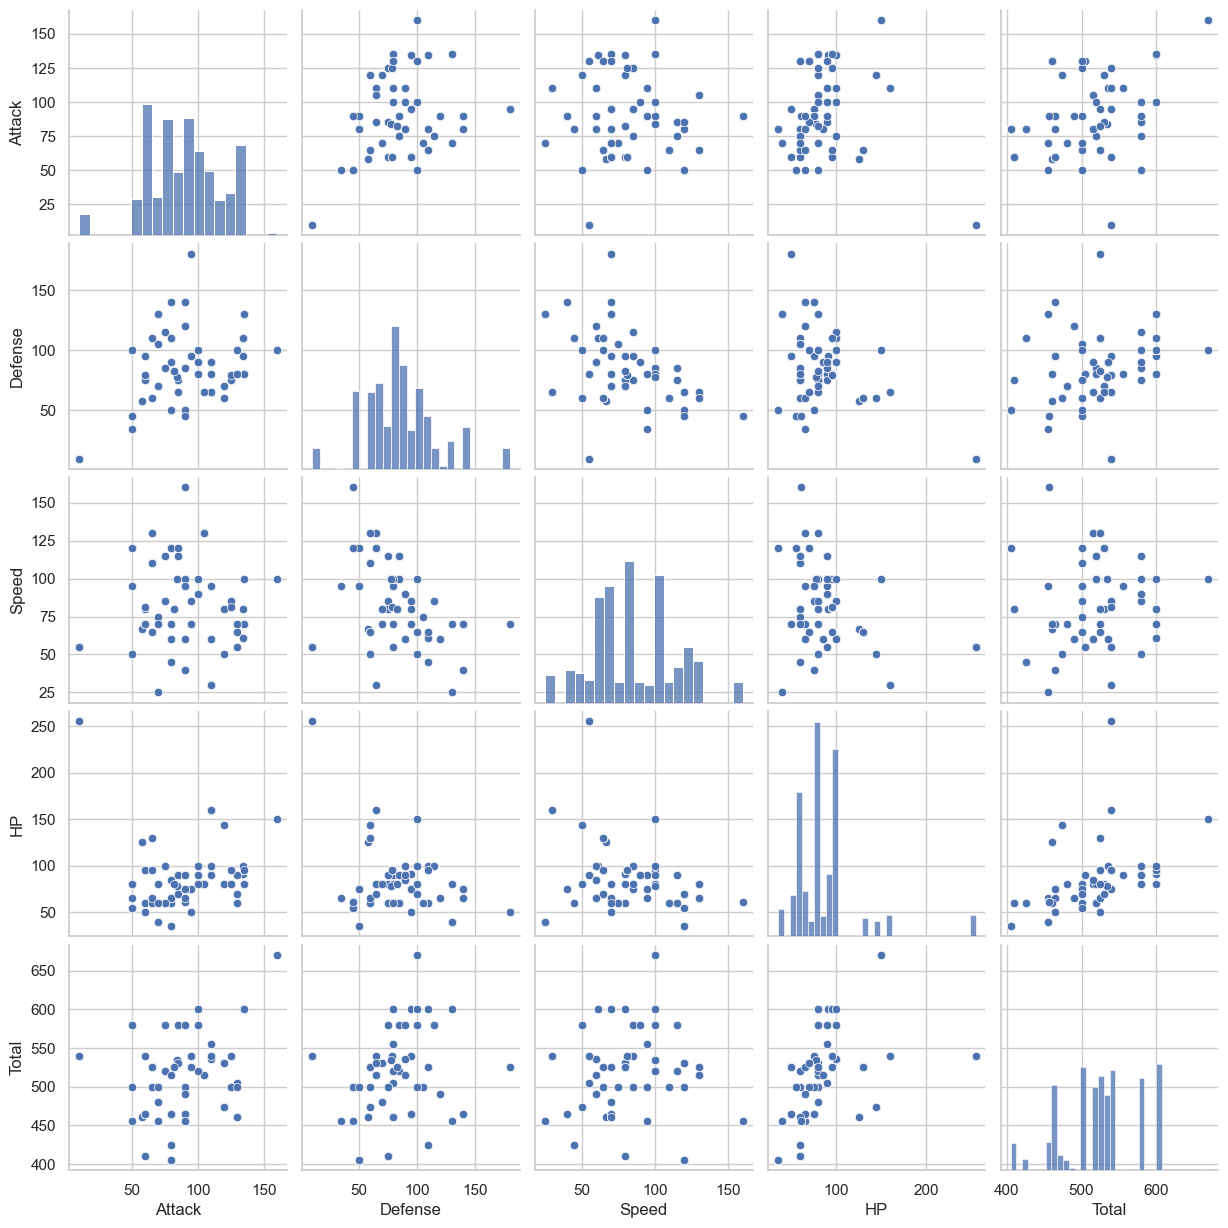

In [23]:
sns.pairplot(df[['Attack','Defense','Speed','HP','Total']])

In [25]:
type_attack = df.groupby('Type1')['Attack'].mean().sort_values(ascending=False)
type_attack.head(10)

Type1
Dragon      134.925926
Rock        119.500000
Steel       105.000000
Grass       103.894737
Fighting    103.571429
Bug         102.756410
Fire        101.315789
Poison       90.000000
Water        86.297561
Ground       82.808989
Name: Attack, dtype: float64

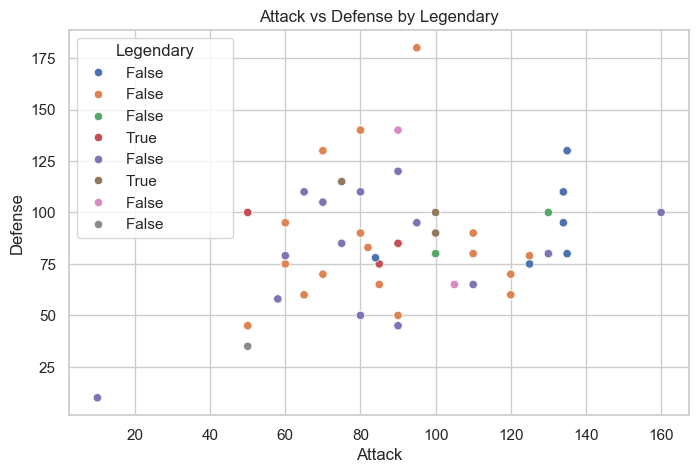

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Attack', y='Defense', hue='Legendary')
plt.title("Attack vs Defense by Legendary")
plt.show()

In [27]:
legendary = df[df['Legendary']==True]['Total']
non_legendary = df[df['Legendary']==False]['Total']

stat, p_value = ttest_ind(legendary, non_legendary)

print("T-Statistic:", stat)
print("P-Value:", p_value)

T-Statistic: nan
P-Value: nan


c:\Users\dell\anaconda3\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [ ]:
''' Hypothesis Testing Insight

- Null Hypothesis: Legendary and Non-Legendary Pokémon have equal mean stats
- If p-value < 0.05 → Reject Null Hypothesis

👉 Conclusion: Legendary Pokémon have significantly higher stats.'''

In [28]:
features = df[['Attack','Defense','Speed','HP']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)

df[['Attack','Defense','Speed','HP','Cluster']].head()

,Attack,Defense,Speed,HP,Cluster
0,134,110,61,100,0
1,135,130,70,80,0
2,110,90,60,100,0
3,135,80,100,95,1
4,65,60,110,60,1


In [29]:
df.groupby('Cluster')[['Attack','Defense','Speed','HP']].mean()

,Attack,Defense,Speed,HP
Cluster,,,,
0,87.984375,117.265625,63.093750,76.328125
1,92.959184,74.027211,101.938776,77.137755
2,72.891304,47.728261,49.880435,174.750000


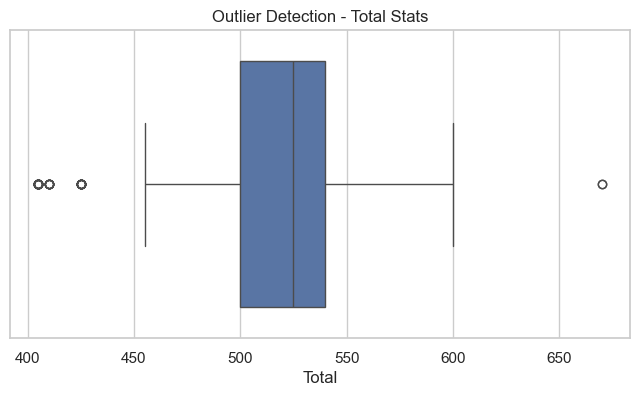

In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Total'])
plt.title("Outlier Detection - Total Stats")
plt.show()

In [32]:
df['Rank'] = df['Total'].rank(ascending=False)

top10 = df.sort_values(by='Total', ascending=False).head(10)
top10[['Pokemon', 'Total', 'Rank']]


,Pokemon,Total,Rank
948,Slaking,670,1.5
868,Slaking,670,1.5
0,Tyranitar,600,66.0
156,Dragonite,600,66.0
601,Metagross,600,66.0
160,Tyranitar,600,66.0
161,Metagross,600,66.0
600,Tyranitar,600,66.0
928,Celebi,600,66.0
165,Salamence,600,66.0
